In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv('spam.csv')

print("First 5 rows of the dataset:")
display(data.head())

print("\nDataset Information:")
data.info()

print("\nSummary statistics:")
display(data.describe())

print("\nMissing values in each column:")
print(data.isnull().sum())

First 5 rows of the dataset:


,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB

Summary statistics:


,Category,Message
count,5572,5572
unique,2,5157
top,ham,"Sorry, I'll call later"
freq,4825,30



Missing values in each column:
Category    0
Message     0
dtype: int64


In [ ]:
data = data[['Category', 'Message']]
data.columns = ['label', 'message']

data['label'] = data['label'].map({'ham': 0, 'spam': 1})

data = data.dropna()

data = data.drop_duplicates()

print("Dataset shape after cleaning:", data.shape)
display(data.head())

Dataset shape after cleaning: (5157, 2)


,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
cv = CountVectorizer()

X = cv.fit_transform(data['message'])

vector_table = pd.DataFrame(X.toarray(), columns=cv.get_feature_names_out())

vector_table.insert(0, 'Message', data['message'].values)

print("Vector Table Example:")
display(vector_table.head(3))

Vector Table Example:


,Message,00,000,000pes,008704050406,0089,0121,01223585236,01223585334,0125698789,...,zhong,zindgi,zoe,zogtorius,zoom,zouk,zyada,èn,ú1,〨ud
0,"Go until jurong point, crazy.. Available only ...",0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Ok lar... Joking wif u oni...,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
X = vector_table.drop(columns=['Message'])
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (4125, 8709)
Testing data shape: (1032, 8709)


In [ ]:
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

spam_words = X_train[y_train == 1].sum(axis=0)
ham_words  = X_train[y_train == 0].sum(axis=0)


In [ ]:
nb = MultinomialNB()

nb.fit(X_train, y_train)

y_pred = nb.predict(X_test)

print("Model Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

spam_prior = np.mean(y_train)
ham_prior = 1 - spam_prior

print("\nPrior Probabilities:")
print(f"P(Spam) = {spam_prior:.4f}")
print(f"P(Ham)  = {ham_prior:.4f}")

spam_words = X_train[y_train == 1].sum(axis=0)
ham_words = X_train[y_train == 0].sum(axis=0)

total_spam_words = spam_words.sum()
total_ham_words = ham_words.sum()

vocab_size = X_train.shape[1]

spam_likelihoods = (spam_words + 1) / (total_spam_words + vocab_size)
ham_likelihoods = (ham_words + 1) / (total_ham_words + vocab_size)

print("\nLikelihoods computed (with Laplace smoothing).")

sample_message = ["Win a free ticket now"]
sample_vector = cv.transform(sample_message).toarray()

log_prob_spam = np.log(spam_prior) + (sample_vector * np.log(spam_likelihoods.values)).sum()
log_prob_ham  = np.log(ham_prior)  + (sample_vector * np.log(ham_likelihoods.values)).sum()

prediction = 1 if log_prob_spam > log_prob_ham else 0

print("\n Manual Prediction for message:", sample_message[0])
print(f"Predicted class: {'Spam' if prediction == 1 else 'Ham'}")


Model Evaluation:
Accuracy: 0.9689922480620154

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.97      0.98       896
           1       0.83      0.96      0.89       136

    accuracy                           0.97      1032
   macro avg       0.91      0.96      0.94      1032
weighted avg       0.97      0.97      0.97      1032


Confusion Matrix:
 [[870  26]
 [  6 130]]

Prior Probabilities:
P(Spam) = 0.1224
P(Ham)  = 0.8776

Likelihoods computed (with Laplace smoothing).

 Manual Prediction for message: Win a free ticket now
Predicted class: Spam


In [ ]:
spam_likelihoods_np = spam_likelihoods.values
ham_likelihoods_np = ham_likelihoods.values

def predict_message(message_vector):
    message_vector = message_vector.values.flatten() if hasattr(message_vector, "values") else message_vector.flatten()

    log_prob_spam = np.log(spam_prior) + (message_vector * np.log(spam_likelihoods_np)).sum()
    log_prob_ham  = np.log(ham_prior)  + (message_vector * np.log(ham_likelihoods_np)).sum()

    return 1 if log_prob_spam > log_prob_ham else 0

y_pred = np.array([predict_message(X_test.iloc[i]) for i in range(len(X_test))])

for i in range(5):
    print(f"Message {i}: Prediction = {y_pred[i]}, Actual = {y_test.iloc[i]}")

accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy on test data: {accuracy:.4f}")


Message 0: Prediction = 0, Actual = 0
Message 1: Prediction = 0, Actual = 0
Message 2: Prediction = 0, Actual = 0
Message 3: Prediction = 0, Actual = 0
Message 4: Prediction = 0, Actual = 1

Accuracy on test data: 0.9690


Confusion Matrix:
[[870  26]
 [  6 130]]

Accuracy:  0.9690
Precision: 0.8333
Recall:    0.9559
F1-score:  0.8904

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.97      0.98       896
        Spam       0.83      0.96      0.89       136

    accuracy                           0.97      1032
   macro avg       0.91      0.96      0.94      1032
weighted avg       0.97      0.97      0.97      1032



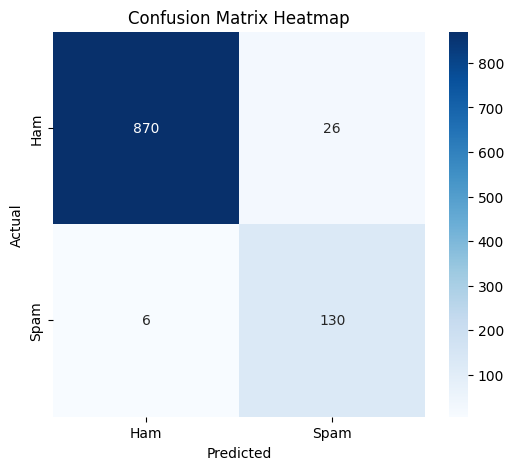

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print(f"\nAccuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()
